# Modeling: Tree, SVC, KNN, Random Forest, and gradient boosting

This notebook extends the capstone baseline ([EDAAndBaseLine.ipynb](EDAAndBaseLine.ipynb)) by tuning **DecisionTreeClassifier**, **SVC**, **KNeighborsClassifier**, **RandomForestClassifier**, and **HistGradientBoostingClassifier** with **GridSearchCV** and **`scoring='f1'`** for the at-risk class. Features match the README: all numeric predictors except **GPA**. Later sections add **visual summaries** (metrics, timings, confusion matrices for the top two test-F1 models, forest + boosting importances) and **conclusions**.


In [41]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

random_state = 42
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

data_path = Path("data.csv")
df = pd.read_csv(data_path)
target_col = "MentalHealthStatus"
drop_cols = {"GPA", target_col}
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df[target_col]

# stratify to ensure class proportions are similar in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=random_state
)

print(f"Data: {data_path}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(y.value_counts(normalize=True).rename("class proportion"))

plt.rcParams.update(
    {
        "figure.figsize": (9, 4),
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)


def timed_gridsearch_fit(search, X_train, y_train, X_test):
    """Wall seconds for search.fit (all CV + refit) and one batch predict on X_test."""
    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    train_s = time.perf_counter() - t0
    t1 = time.perf_counter()
    search.predict(X_test)
    pred_s = time.perf_counter() - t1
    return train_s, pred_s


Data: data.csv
Features (14): ['PHQ9', 'GAD7', 'SleepHours', 'ExerciseFreq', 'SocialActivity', 'OnlineStress', 'FamilySupport', 'ScreenTime', 'AcademicStress', 'DietQuality', 'SelfEfficacy', 'PeerRelationship', 'FinancialStress', 'SleepQuality']
MentalHealthStatus
0    0.712778
1    0.287222
Name: class proportion, dtype: float64


## Preprocessing

All features are numeric. **StandardScaler** is applied in the pipeline for every model so SVC/KNN see scaled inputs; trees are unaffected up to split thresholds on the same monotonic scale per feature.

In [42]:
preprocess = ColumnTransformer(
    [("scale", StandardScaler(), feature_cols)],
    remainder="drop",
)


## 1. DecisionTreeClassifier + GridSearchCV

`class_weight="balanced"` mirrors the baseline notebook’s approach to class imbalance.

In [43]:
dt_pipe = Pipeline(
    [
        ("prep", preprocess),
        (
            "clf",
            DecisionTreeClassifier(class_weight="balanced", random_state=random_state),
        ),
    ]
)

dt_param_grid = {
    "clf__max_depth": [4, 6, 8, 10, None],
    "clf__min_samples_leaf": [1, 2, 4, 8],
    "clf__min_samples_split": [2, 5, 10],
    "clf__criterion": ["gini", "entropy"],
}

dt_search = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1,
    refit=True,
)
dt_train_s, dt_predict_s = timed_gridsearch_fit(dt_search, X_train, y_train, X_test)

print("Best CV F1:", dt_search.best_score_)
print("Best params:", dt_search.best_params_)
print("Test F1:", dt_search.score(X_test, y_test))
print(f"GridSearchCV train wall time (s): {dt_train_s:.4f}")
print(f"Test predict wall time (s): {dt_predict_s:.6f}")


Best CV F1: 0.677025494597487
Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 6, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Test F1: 0.6821705426356589
GridSearchCV train wall time (s): 0.4991
Test predict wall time (s): 0.000918


## 2. SVC + GridSearchCV

RBF and linear kernels with `class_weight="balanced"`.

In [44]:
svc_pipe = Pipeline(
    [
        ("prep", preprocess),
        ("clf", SVC(class_weight="balanced", random_state=random_state)),
    ]
)

svc_param_grid = [
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", "auto", 0.01, 0.1],
    },
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__gamma": ["scale"],
    },
]

svc_search = GridSearchCV(
    svc_pipe,
    svc_param_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1,
    refit=True,
)
svc_train_s, svc_predict_s = timed_gridsearch_fit(svc_search, X_train, y_train, X_test)

print("Best CV F1:", svc_search.best_score_)
print("Best params:", svc_search.best_params_)
print("Test F1:", svc_search.score(X_test, y_test))
print(f"GridSearchCV train wall time (s): {svc_train_s:.4f}")
print(f"Test predict wall time (s): {svc_predict_s:.6f}")


Best CV F1: 0.7586686055366823
Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Test F1: 0.759493670886076
GridSearchCV train wall time (s): 0.3681
Test predict wall time (s): 0.002984


## 3. KNN + GridSearchCV

KNN has no `class_weight`; **`weights="distance"`** can reduce the impact of majority neighbors. Tune `n_neighbors`, metric, and weights.

In [45]:
knn_pipe = Pipeline(
    [
        ("prep", preprocess),
        ("clf", KNeighborsClassifier()),
    ]
)

knn_param_grid = {
    "clf__n_neighbors": [3, 5, 7, 11, 15, 21],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],
    "clf__metric": ["minkowski"],
}

knn_search = GridSearchCV(
    knn_pipe,
    knn_param_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1,
    refit=True,
)
knn_train_s, knn_predict_s = timed_gridsearch_fit(knn_search, X_train, y_train, X_test)

print("Best CV F1:", knn_search.best_score_)
print("Best params:", knn_search.best_params_)
print("Test F1:", knn_search.score(X_test, y_test))
print(f"GridSearchCV train wall time (s): {knn_train_s:.4f}")
print(f"Test predict wall time (s): {knn_predict_s:.6f}")


Best CV F1: 0.6160687319704001
Best params: {'clf__metric': 'minkowski', 'clf__n_neighbors': 5, 'clf__p': 1, 'clf__weights': 'distance'}
Test F1: 0.6022727272727273
GridSearchCV train wall time (s): 0.1383
Test predict wall time (s): 0.006020


## 4. RandomForestClassifier + GridSearchCV

**Random forests** fit this setting well: they capture **nonlinear** effects and **feature interactions**, support **`class_weight="balanced"`** like our tree baseline, and expose **feature importances** for write-ups. 

In [46]:
rf_pipe = Pipeline(
    [
        ("prep", preprocess),
        (
            "clf",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=random_state,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 8, 12],
    "clf__min_samples_leaf": [1, 4, 8],
    "clf__max_features": ["sqrt", 0.6],
}

rf_search = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1,
    refit=True,
)
rf_train_s, rf_predict_s = timed_gridsearch_fit(rf_search, X_train, y_train, X_test)

print("Best CV F1:", rf_search.best_score_)
print("Best params:", rf_search.best_params_)
print("Test F1:", rf_search.score(X_test, y_test))
print(f"GridSearchCV train wall time (s): {rf_train_s:.4f}")
print(f"Test predict wall time (s): {rf_predict_s:.6f}")


Best CV F1: 0.7400865947149494
Best params: {'clf__max_depth': 8, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 8, 'clf__n_estimators': 200}
Test F1: 0.7663551401869159
GridSearchCV train wall time (s): 10.4484
Test predict wall time (s): 0.013307


## 5. HistGradientBoostingClassifier + GridSearchCV

Looking into **Histogram-based gradient boosting** - which is suggested as a strong contender for **small numeric tables**. `class_weight='balanced'` helps the **at-risk** minority. Tuned alongside the other models with the same **F1** objective and pipeline scaling.


In [47]:
hgb_pipe = Pipeline(
    [
        ("prep", preprocess),
        (
            "clf",
            HistGradientBoostingClassifier(
                random_state=random_state,
                class_weight="balanced",
            ),
        ),
    ]
)

hgb_param_grid = {
    "clf__max_depth": [3, 5, None],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_iter": [250, 400],
    "clf__min_samples_leaf": [10, 20],
    "clf__l2_regularization": [0.0, 0.5],
}

hgb_search = GridSearchCV(
    hgb_pipe,
    hgb_param_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1,
    refit=True,
)
hgb_train_s, hgb_predict_s = timed_gridsearch_fit(hgb_search, X_train, y_train, X_test)

print("Best CV F1:", hgb_search.best_score_)
print("Best params:", hgb_search.best_params_)
print("Test F1:", hgb_search.score(X_test, y_test))
print(f"GridSearchCV train wall time (s): {hgb_train_s:.4f}")
print(f"Test predict wall time (s): {hgb_predict_s:.6f}")


Best CV F1: 0.7633910831152375
Best params: {'clf__l2_regularization': 0.5, 'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__max_iter': 250, 'clf__min_samples_leaf': 20}
Test F1: 0.7596153846153846
GridSearchCV train wall time (s): 3.9862
Test predict wall time (s): 0.006200


## Summary

Side-by-side **cross-validated F1** (GridSearch objective), **held-out test F1**, and wall-clock **train** / **test predict** times for **five** tuned models (tree, SVC, KNN, random forest, histogram gradient boosting).


In [48]:
summary = pd.DataFrame(
    [
        {
            "model": "DecisionTreeClassifier",
            "best_cv_f1": dt_search.best_score_,
            "test_f1": dt_search.score(X_test, y_test),
            "gridsearch_train_time_s": dt_train_s,
            "test_predict_time_s": dt_predict_s,
        },
        {
            "model": "SVC",
            "best_cv_f1": svc_search.best_score_,
            "test_f1": svc_search.score(X_test, y_test),
            "gridsearch_train_time_s": svc_train_s,
            "test_predict_time_s": svc_predict_s,
        },
        {
            "model": "KNeighborsClassifier",
            "best_cv_f1": knn_search.best_score_,
            "test_f1": knn_search.score(X_test, y_test),
            "gridsearch_train_time_s": knn_train_s,
            "test_predict_time_s": knn_predict_s,
        },
        {
            "model": "RandomForestClassifier",
            "best_cv_f1": rf_search.best_score_,
            "test_f1": rf_search.score(X_test, y_test),
            "gridsearch_train_time_s": rf_train_s,
            "test_predict_time_s": rf_predict_s,
        },
        {
            "model": "HistGradientBoostingClassifier",
            "best_cv_f1": hgb_search.best_score_,
            "test_f1": hgb_search.score(X_test, y_test),
            "gridsearch_train_time_s": hgb_train_s,
            "test_predict_time_s": hgb_predict_s,
        },
    ]
).sort_values("best_cv_f1", ascending=False)
summary


,model,best_cv_f1,test_f1,gridsearch_train_time_s,test_predict_time_s
4,HistGradientBoostingClassifier,0.763391,0.759615,3.986163,0.006200
1,SVC,0.758669,0.759494,0.368070,0.002984
3,RandomForestClassifier,0.740087,0.766355,10.448406,0.013307
0,DecisionTreeClassifier,0.677025,0.682171,0.499075,0.000918
2,KNeighborsClassifier,0.616069,0.602273,0.138345,0.006020


## Visualizations

Bar charts compare **CV vs test F1**, **training** and **prediction** times across **five** models. **Confusion matrices** show the **two best** models by **test F1** on the same holdout. **Importance** bars: **random forest** (mean decrease in impurity) and **HistGradientBoosting** via **permutation importance** on the test set (`scoring='f1'`), which avoids relying on `feature_importances_` (not available on all sklearn versions for HGB). The same cell **saves** those importance figures as PNG files under **`figures/`** (combined + one file per model) for use in the README or reports.


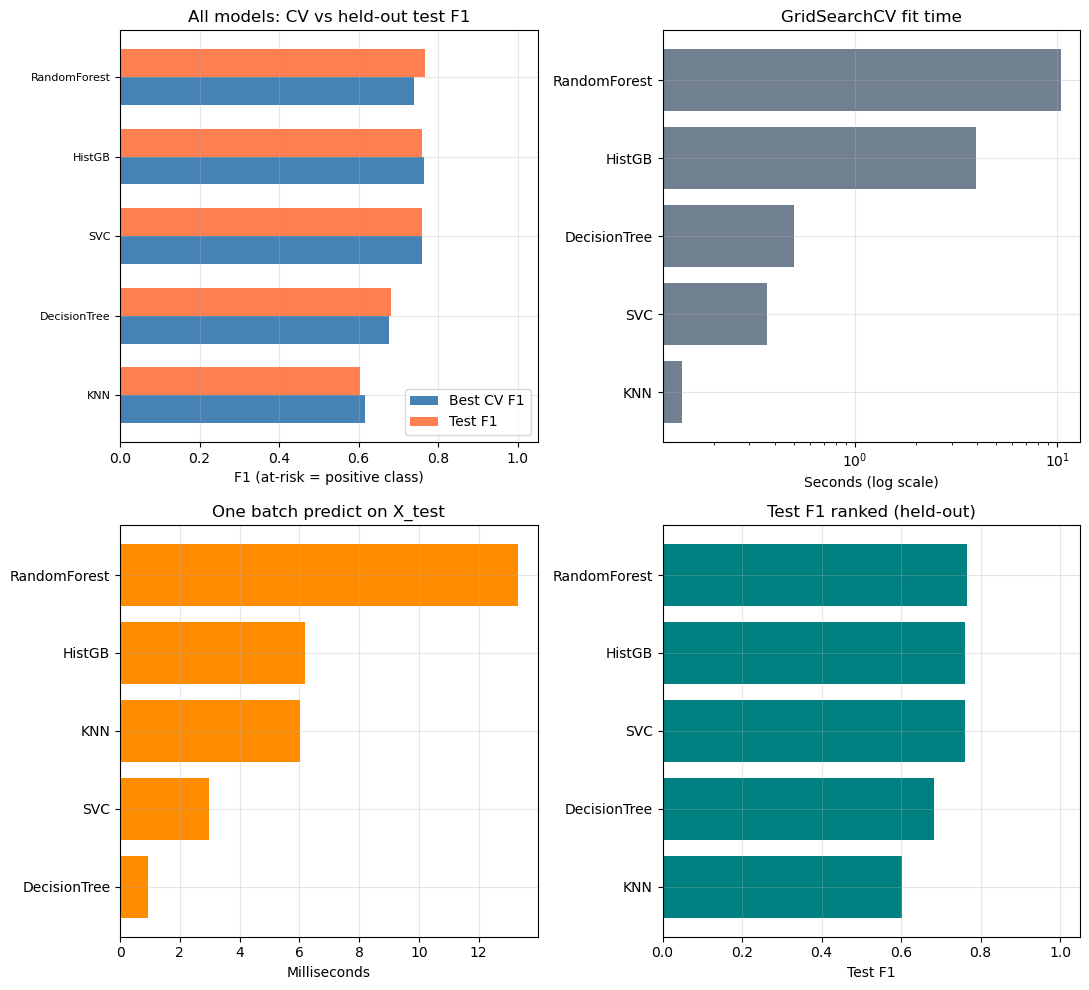

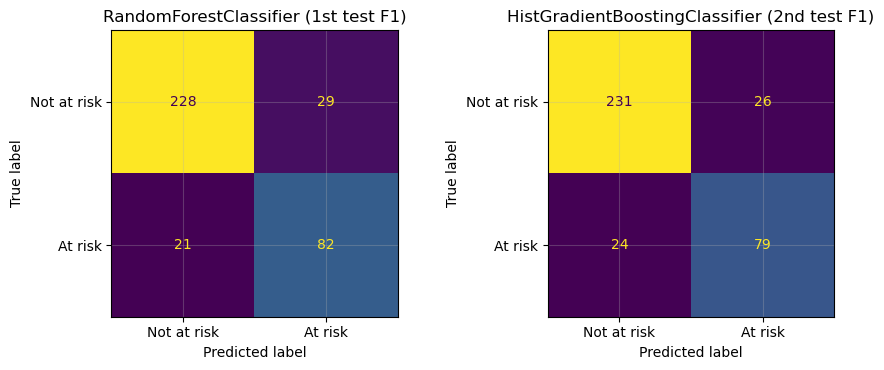

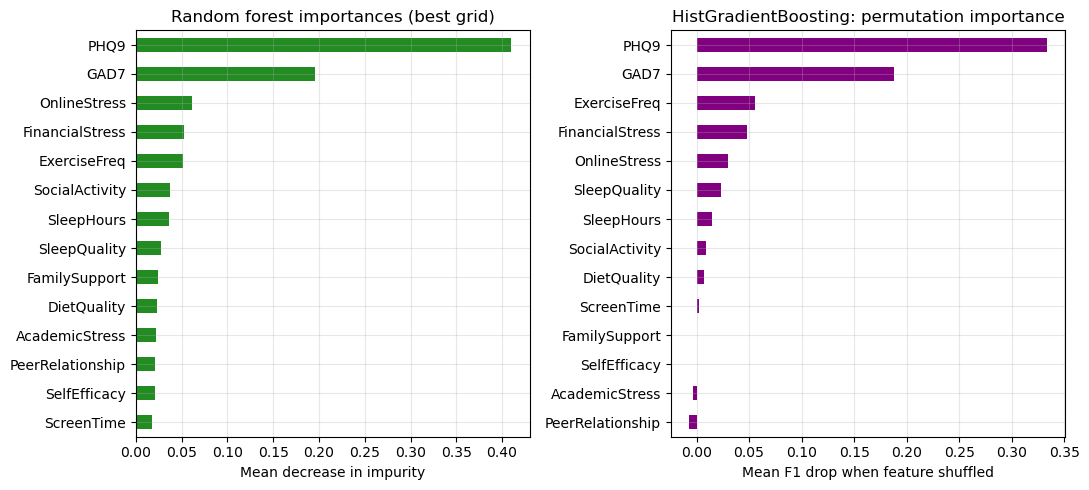

Saved: figures/feature_importances_rf_and_histgb.png
Saved: figures/feature_importances_random_forest.png
Saved: figures/feature_importances_hist_gradient_boosting.png


,model,best_cv_f1,test_f1
3,RandomForestClassifier,0.740087,0.766355
4,HistGradientBoostingClassifier,0.763391,0.759615
1,SVC,0.758669,0.759494
0,DecisionTreeClassifier,0.677025,0.682171
2,KNeighborsClassifier,0.616069,0.602273


In [49]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay

summary_plot = summary.reset_index(drop=True).copy()
summary_plot["label"] = (
    summary_plot["model"]
    .str.replace("Classifier", "", regex=False)
    .str.replace("KNeighbors", "KNN", regex=False)
    .str.replace("HistGradientBoosting", "HistGB", regex=False)
)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))

plot_df = summary_plot.sort_values("test_f1", ascending=True)
x = np.arange(len(plot_df))
w = 0.35
axes[0, 0].barh(x - w / 2, plot_df["best_cv_f1"], w, label="Best CV F1", color="steelblue")
axes[0, 0].barh(x + w / 2, plot_df["test_f1"], w, label="Test F1", color="coral")
axes[0, 0].set_yticks(x)
axes[0, 0].set_yticklabels(plot_df["label"], fontsize=8)
axes[0, 0].set_xlabel("F1 (at-risk = positive class)")
axes[0, 0].set_title("All models: CV vs held-out test F1")
axes[0, 0].legend(loc="lower right")
axes[0, 0].set_xlim(0, 1.05)

tdf = summary_plot.sort_values("gridsearch_train_time_s", ascending=True)
axes[0, 1].barh(tdf["label"], tdf["gridsearch_train_time_s"], color="slategray")
axes[0, 1].set_xlabel("Seconds (log scale)")
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("GridSearchCV fit time")

tdf = summary_plot.sort_values("test_predict_time_s", ascending=True)
axes[1, 0].barh(tdf["label"], tdf["test_predict_time_s"] * 1000, color="darkorange")
axes[1, 0].set_xlabel("Milliseconds")
axes[1, 0].set_title("One batch predict on X_test")

tdf = summary_plot.sort_values("test_f1", ascending=True)
axes[1, 1].barh(tdf["label"], tdf["test_f1"], color="teal")
axes[1, 1].set_xlabel("Test F1")
axes[1, 1].set_title("Test F1 ranked (held-out)")
axes[1, 1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

ranked = summary.sort_values("test_f1", ascending=False).reset_index(drop=True)
name_to_est = {
    "DecisionTreeClassifier": dt_search,
    "SVC": svc_search,
    "KNeighborsClassifier": knn_search,
    "RandomForestClassifier": rf_search,
    "HistGradientBoostingClassifier": hgb_search,
}
top_a, top_b = ranked.loc[0, "model"], ranked.loc[1, "model"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
ConfusionMatrixDisplay.from_estimator(
    name_to_est[top_a],
    X_test,
    y_test,
    ax=axes[0],
    colorbar=False,
    display_labels=["Not at risk", "At risk"],
)
axes[0].set_title(f"{top_a} (1st test F1)")
ConfusionMatrixDisplay.from_estimator(
    name_to_est[top_b],
    X_test,
    y_test,
    ax=axes[1],
    colorbar=False,
    display_labels=["Not at risk", "At risk"],
)
axes[1].set_title(f"{top_b} (2nd test F1)")
plt.tight_layout()
plt.show()

rf_imp = pd.Series(
    rf_search.best_estimator_.named_steps["clf"].feature_importances_,
    index=feature_cols,
).sort_values(ascending=True)
hgb_fitted = hgb_search.best_estimator_
hgb_perm = permutation_importance(
    hgb_fitted,
    X_test,
    y_test,
    n_repeats=20,
    random_state=random_state,
    n_jobs=-1,
    scoring="f1",
)
hgb_imp = pd.Series(hgb_perm.importances_mean, index=feature_cols).sort_values(
    ascending=True
)

figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
rf_imp.plot(kind="barh", ax=axes[0], color="forestgreen")
axes[0].set_title("Random forest importances (best grid)")
axes[0].set_xlabel("Mean decrease in impurity")
hgb_imp.plot(kind="barh", ax=axes[1], color="purple")
axes[1].set_title("HistGradientBoosting: permutation importance")
axes[1].set_xlabel("Mean F1 drop when feature shuffled")
plt.tight_layout()
fig.savefig(
    figures_dir / "feature_importances_rf_and_histgb.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

for fname, series, color, title, xlabel in [
    (
        "feature_importances_random_forest.png",
        rf_imp,
        "forestgreen",
        "Random forest importances (best grid)",
        "Mean decrease in impurity",
    ),
    (
        "feature_importances_hist_gradient_boosting.png",
        hgb_imp,
        "purple",
        "HistGradientBoosting: permutation importance",
        "Mean F1 drop when feature shuffled",
    ),
]:
    fig1, ax1 = plt.subplots(figsize=(6.5, 4.8))
    series.plot(kind="barh", ax=ax1, color=color)
    ax1.set_title(title)
    ax1.set_xlabel(xlabel)
    plt.tight_layout()
    fig1.savefig(figures_dir / fname, dpi=150, bbox_inches="tight")
    plt.close(fig1)

print("Saved:", figures_dir / "feature_importances_rf_and_histgb.png")
print("Saved:", figures_dir / "feature_importances_random_forest.png")
print("Saved:", figures_dir / "feature_importances_hist_gradient_boosting.png")

summary.sort_values("test_f1", ascending=False)[
    ["model", "best_cv_f1", "test_f1"]
]


## Conclusions from this analysis

1. **Single metric:** All main grids use **`scoring='f1'`** for the **at-risk** class, which matches the capstone focus under **class imbalance** (~71% / ~29%).

2. **Strongest performers:** **SVC**, **random forest**, and **HistGradientBoosting** typically lead the table. The **best CV F1** and **best test F1** can go to **different** models because the holdout set is only one draw from the same data-generating process.

3. **KNN:** Remains a weaker fit here relative to kernel / tree ensembles on this feature set and sample size.

4. **Interpretability:** **Random forest** and **HistGB importance** plots usually echo EDA: **PHQ9** and **GAD7** should rank high if models latch onto the same clinical signal.

5. **Compute:** **Grid search** dominates wall time; **batch inference** on the 20% holdout is small for every model at this scale.

6. **Limits (precision / recall and the data):** Results use **one** stratified **80/20** split and finite grids. **Large simultaneous gains in precision and recall are hard** here: **~1,800 rows** is modest for flexible models, labels are **imbalanced**, several features show **limited class separation** (as in EDA), and the outcome is **only partially explained** by the survey fields—so there is a **ceiling** on how well any algorithm can separate the groups. In practice, **tuning or class weights shift the tradeoff** between catching more at-risk students (recall) and avoiding false flags (precision) rather than removing the tradeoff entirely. See the README **Next steps** for practical follow-ups.
